# Text Analytics
## Assignment on CNNs

- Georgios Boufis, *f3352504*, *geo.boufis@aueb.gr*
- Leonidha Mara, *f3352514*, *leo.mara@aueb.gr*

In [1]:
# Installing wget to download files and gensim for word embeddings
!pip install --upgrade wget --quiet
! pip install gensim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 68.6 MB/s eta 0:00:00


In [2]:
%pip install --upgrade gensim numpy umap-learn matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 58.9 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import re
import string
import os
import gensim.downloader as api
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

import random

from tqdm import tqdm
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


import copy
from itertools import product
import time


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
SEED = 42

# Python's random
random.seed(SEED)

# NumPy's random
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [5]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


### Dataset Loading

We are using the IMDb Movie Reviews dataset for sentiment analysis. Here we download the data, extracts it and load it to our environment.

In [6]:
# Downloading the aclImdb dataset from Stanford's server
import wget
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = wget.download(url)
print(filename)

aclImdb_v1.tar.gz


In [7]:
# Extracting the compressed tar file to access the review folders
%%capture
!tar xvzf aclImdb_v1.tar.gz

In [8]:
# Loading the files from the 'neg' and 'pos' directories
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split

train = load_files("aclImdb/train", categories=['neg', 'pos'], encoding="utf-8")
test  = load_files("aclImdb/test",  categories=['neg', 'pos'], encoding="utf-8")

# Combining them to create a full dataset for custom splitting later
x = train.data + test.data
y = list(train.target) + list(test.target)


In [9]:
print(train.target_names)

['neg', 'pos']


In [10]:
# First sample and target
print(f'Sample: {x[0]} \nTarget: {y[0]}')

Sample: Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mutual suicide via slaughtering their classmates. It captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own/mutual world via coupled destruction.<br /><br />It is not a perfect movie but given what money/time the filmmaker and actors had - it is a remarkable product. In terms of explaining the motives and actions of the two young suicide/murderers it is better than 'Elephant' - in terms of being a film that gets under our 'rationalistic' skin it is a far, far better film than almost anything you are likely to see. <br /><br />Flawed but honest with a terrible honesty. 
Target: 1


**Data Visualization**

Total Dataset Size: We have a total of 50,000 reviews, which is a large enough sample to train a reliable model.

Perfect Balance: The dataset is perfectly split with 25,000 negative (50%) and 25,000 positive (50%) reviews. This is great because the model won't be biased toward one specific sentiment.

Review Length Variation: * Reviews vary a lot in size. The shortest is only 4 words, while the longest reaches 2,470 words.

Our mean is 231.2 words while the median is only 173.0. In a symmetrical distribution, these would be the same. Since the mean is significantly higher, it shows the average is being pulled to the right by very long reviews.

We have a maximum length of 2,470 words, which is huge compared to the median. These long reviews form the "long tail" on the right side of the histogram.

Most reviews are concentrated on the shorter end (near the 173-word mark), while the distribution stretches out much further toward the higher word counts.

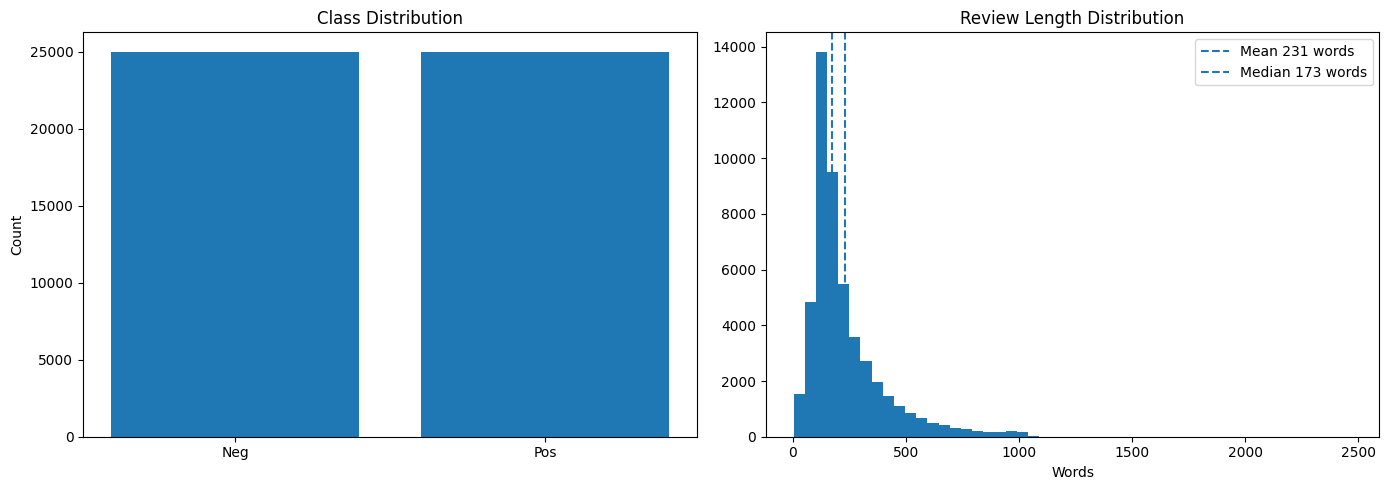


Total Reviews: 50000
Neg: 25000 (50.0%)
Pos: 25000 (50.0%)

Length stats:
Min: 4
Max: 2470
Mean: 231.2
Median: 173.0
Std: 171.3



In [11]:


# Visualizing how many reviews we have per class and their word counts
counts = np.bincount(y)
lengths = [len(r.split()) for r in x]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
ax[0].bar(range(len(counts)), counts)
ax[0].set_xticks(range(len(counts)))
ax[0].set_xticklabels(['Neg', 'Pos'])
ax[0].set_title("Class Distribution")
ax[0].set_ylabel("Count")

# Review length distribution
ax[1].hist(lengths, bins=50)
ax[1].axvline(np.mean(lengths), linestyle="--", label=f"Mean {np.mean(lengths):.0f} words")
ax[1].axvline(np.median(lengths), linestyle="--", label=f"Median {np.median(lengths):.0f} words")
ax[1].set_title("Review Length Distribution")
ax[1].set_xlabel("Words")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"""
Total Reviews: {len(x)}
Neg: {counts[0]} ({counts[0]/len(x)*100:.1f}%)
Pos: {counts[1]} ({counts[1]/len(x)*100:.1f}%)

Length stats:
Min: {min(lengths)}
Max: {max(lengths)}
Mean: {np.mean(lengths):.1f}
Median: {np.median(lengths):.1f}
Std: {np.std(lengths):.1f}
""")

Here, we split our dataset. First, we give 10% to test set and 90% to train and development set, and finally we split the 90% of train+dev into 20% to dev and 70% on train. So, that means that we have 72% on train, 18% on development and 10% on test subsets.
As a result, we have 36000 for train, 9000 for validation and 5000 for test.


In [12]:
# First, we split the total data: 90% stays for training/validation and 10% is set aside for the final test
X_temp, X_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.1,
    random_state=42
)

# Then, we take that 90% (X_temp) and split it again:
# 80% for the actual training and 20% for validation (tuning)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2,
    stratify=y_temp,
    random_state=42
)

# Printing the final sizes to confirm the split worked
print(f"train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

train: 36000, val: 9000, test: 5000


In [13]:
print(f'Number of training examples: {len(X_train)}')
print(f'Categories: {np.unique(y_train)}')

Number of training examples: 36000
Categories: [0 1]


In [14]:
avg_length = int(np.mean([len(re.sub(r'[^a-zA-Z]', ' ', text.lower()).split()) for text in X_train]))


In [15]:
print(f'Training corpus average text length: {avg_length}')


Training corpus average text length: 238


We define the function clean_text with argument text and we apply all the above:
1. Convert all letters to lowercase
2. Remove HTML tags
3. Remove underscores
4. Remove special characters
5. Remove numbers
6. Remove extra whitespaces

In [16]:
def clean_text(text):

  if not isinstance(text, str):
    return ""

  # Convert to lowercase
  text = text.lower()

  # Remove HTML tags
  text = re.sub(r'<[^>]*>', '', text)

  # Remove underscores
  text = re.sub(r'_', ' ', text)

  # Remove special characters
  text = re.sub(r'[^a-zA-Z0-9\s-]', '', text)

  # Remove numbers
  text = re.sub(r'\d+', '', text)

  # Remove extra whitespaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

Now, we define the tokenize function, that remove all the useless english words, with **stopwords**, we call clean_text function that we apply before to clean the text, after that we split the text into sentences with **sent_tokenize** and finally we split the sentences into words with **word_tokenize**

In [17]:
def tokenize(data):



    # Stopwords
    stop_words = stopwords.words('english')
    stop_words.extend(string.punctuation)

    # Add custom stopwords for movie reviews
    stop_words.extend([
        'the', 'of', 'and', 'as', 'a', 'to', 'in', 'on', 'for',
        'film', 'movie', 'watch', 'seen', 'time',

    ])

    tokenized_samples = []

    for sample in data:
        # Clean the text
        cleaned_text = clean_text(sample)

        if  cleaned_text:
            tokens = []

            # Split into sentences
            sentences = sent_tokenize(cleaned_text)

            for sent in sentences:
               # Tokenize into words
               words = word_tokenize(sent)

               for word in words:
                   # Filter stopwords
                   if word.lower() not in stop_words and word.strip():
                      tokens.append(word.lower())
            if tokens:
              tokenized_samples.append(tokens)

    return tokenized_samples


We make sure that all our data (Train, Val, and Test) is processed in the exact same way. By tokenizing once and saving the results into these variables, we don't have to keep re-processing the raw text every time we want to try a different model.

In [18]:
X_train_tokenized = tokenize(X_train)
X_val_tokenized = tokenize(X_val)
X_test_tokenized = tokenize(X_test)

### Data Post-Processing: Tokens to Text
We use the function **tokens_to_text** which convert tokens back to text, which is often a necessary step before vectorization.
The function **tokens_to_text** iterates through a list of tokenized documents and joins the individual words back into single strings.
The function is applied to each subset (train, validation, test).
Then, it calculates the average number of tokens per document, since it helps us to identify if the preprocessing was agressive.
Finally, we print the original text and the processed text and the first 15 tokens of the tokenized train set to see if it works well.

In [19]:
# CONVERT TOKENS BACK TO TEXT
def tokens_to_text(token_lists):
    """Convert list of token lists to list of text strings"""
    text_strings = []
    for tokens in token_lists:
      if tokens: # Only if tokens exist
         text = ' '.join(tokens)  # Join tokens with space
         text_strings.append(text)
      else:
        text_strings.append('') # Empty string if no tokens
    return text_strings

# APPLY TO ALL DATASETS

print("Converting tokens back to text...")
X_train_processed = tokens_to_text(X_train_tokenized)
X_val_processed = tokens_to_text(X_val_tokenized)
X_test_processed = tokens_to_text(X_test_tokenized)


print(f"X_train_processed: {len(X_train_processed)} texts")
print(f"X_val_processed: {len(X_val_processed)} texts")
print(f"X_test_processed: {len(X_test_processed)} texts")

avg_train = np.mean([len(t) for t in X_train_tokenized if t])
avg_val = np.mean([len(t) for t in X_val_tokenized if t])
avg_test = np.mean([len(t) for t in X_test_tokenized if t])

print(f"\nAverage tokens per document:")
print(f"  Train: {avg_train:.0f}")
print(f"  Val: {avg_val:.0f}")
print(f"  Test: {avg_test:.0f}")

print(f"\nOriginal text (first 200 chars):")
print(X_train[0][:200])

print(f"\nProcessed text (first 200 chars):")
print(X_train_processed[0][:200])


print(f"\nFirst 15 tokens:")
print(X_train_tokenized[0][:20])

Converting tokens back to text...
X_train_processed: 36000 texts
X_val_processed: 9000 texts
X_test_processed: 5000 texts

Average tokens per document:
  Train: 115
  Val: 114
  Test: 116

Original text (first 200 chars):
*Warning! Some spoilers!*<br /><br />Matt, a rich writer, is in fact still just a boy in his behaviour. He doesn't care about anyone's but his own needs and couldn't care less about the consequences o

Processed text (first 200 chars):
warning spoilersmatt rich writer fact still boy behaviour doesnt care anyones needs couldnt care less consequences actions gets know nimi bonds familiy communitiy starts feel something missing livehe 

First 15 tokens:
['warning', 'spoilersmatt', 'rich', 'writer', 'fact', 'still', 'boy', 'behaviour', 'doesnt', 'care', 'anyones', 'needs', 'couldnt', 'care', 'less', 'consequences', 'actions', 'gets', 'know', 'nimi']


We use **CountVectorizer** to identify the most frequent words in our training set. We set a limit at the vocabulary at the top 5000 words to keep the model efficient.
We create a new dictionary (vocab). It reserves index 0 for <PAD> and index 1 for <UNK>, shifting all other word indices by 2.
Then, we download **word2vec**, which contains 300-dimensional vectors for millions of words. We create the **embedding matrix**, which has the size of the word2vec.vector size. It is logical that not every word of the 5000 will exist in the word2vec dataset, so what we do is that if the word exists in word2vec then we take the corresponding embedding of this word, else if the word is not exists in the word2vec we assigned it to **average_embedding** matrix and we can see from the results that 81 words are not exists at the word2vec.
Finally, the final shape of the embedding matrix will be: (Vocab_size + 2, 300)

In [20]:
vectorizer = CountVectorizer(max_features=5000) # create a dict with 5000 most frequent words
vectorizer.fit(X_train_processed) # learn from the training data, choose the top 5000
custom_vocab = vectorizer.vocabulary_ # extract vocabulary as dictionary

print(f"Vocabulary size: {len(custom_vocab)}")

# Load Word2Vec embeddings
word2vec = api.load('word2vec-google-news-300')

# Create embedding matrix
embedding_dim = word2vec.vector_size # take the size of word2vec, which is 300
average_embedding = np.mean(word2vec.vectors, axis=0) # Average all embeddings

# Create vocab dict with special tokens <PAD> and <UNK>
vocab = {'<PAD>': 0, '<UNK>': 1}
vocab.update({word: idx + 2 for idx, word in enumerate(custom_vocab)}) # it adds 2, because we have ID:0 for <PAD> and ID:1 for <UNK>


# Create a 2-D Embedding Matrix
embedding_matrix = np.zeros((len(vocab), embedding_dim)) # (5002, 300)

# PAD token embedding (zeros)
embedding_matrix[0] = np.zeros(embedding_dim)

# UNK token embedding (average), for UNK words take the mean value of all the word2vec embeddings
embedding_matrix[1] = average_embedding

# Fill embedding matrix for all other words
oov_count = 0 # Out-Of-Vocabulary counter


for word, idx in vocab.items():
  if word in word2vec.key_to_index: # Check if the word exists in Word2Vec
    embedding_matrix[idx] = word2vec[word] # Take the corresponding embedding of the word
  else: # For words not in Word2Vec except from the tokens  PAD and UNK
    embedding_matrix[idx] = average_embedding
    oov_count += 1





#Clean up memory
del word2vec

print(f"\nSummary:")
print(f" Final Vocabulary size: {len(vocab)}")
print(f"  Embedding dim: {embedding_dim}")
print(f"  Embedding matrix shape: {embedding_matrix.shape}")
print(f"  OOV words: {oov_count} ({100*oov_count/len(vocab):.2f}%)")

Vocabulary size: 5000
[==================================================] 100.0% 1662.8/1662.8MB downloaded

Summary:
 Final Vocabulary size: 5002
  Embedding dim: 300
  Embedding matrix shape: (5002, 300)
  OOV words: 75 (1.50%)


### Text to IDs
Models cannot multiply a word, they require a unique integer representation for every token. We create an empty list with the name sequences, and for every text in texts we split it into words and then convert each word to its IDs. For every word  if the word exists in vocabulary then we add the known word to the list of ids and if the word is <UNK> then we add the <UNK> (with index 1) token also to ids list and finally we append the ids list to the initial sequences list.
Finally, we apply the **text_to_ids** function to all sets.
Also, we calculate the Average Sequence Length, because it will helps us with the Padding after.

In [21]:
def text_to_ids(texts, vocab):
  """
  Convert text documents to sequences of word IDs
  text: List of text strings
  vocab: Dictionary mapping words to IDs
  Return: List of sequences, each sequence is a list of word IDs
  """

  sequences = []

  for text in texts:
    # Split text into words
    words = text.split()

    # Convert each word to its IDs
    ids = []
    for word in words:
      if word in vocab:
        ids.append(vocab[word]) # Known word
      else:
        ids.append(vocab['<UNK>']) # Unknown word -> UNK token
    sequences.append(ids)

  return sequences



# Apply to all datasets

X_train_ids = text_to_ids(X_train_processed, vocab)

X_val_ids = text_to_ids(X_val_processed, vocab)

X_test_ids = text_to_ids(X_test_processed, vocab)


print(f"\nDataset sizes:")
print(f"  X_train_ids: {len(X_train_ids)} sequences")
print(f"  X_val_ids: {len(X_val_ids)} sequences")
print(f"  X_test_ids: {len(X_test_ids)} sequences")


# Average sequence length
avg_train_len = np.mean([len(seq) for seq in X_train_ids])
avg_val_len = np.mean([len(seq) for seq in X_val_ids])
avg_test_len = np.mean([len(seq) for seq in X_test_ids])


print(f"\nAverage sequence length (in word IDs):")
print(f"  Train: {avg_train_len:.0f}")
print(f"  Val: {avg_val_len:.0f}")
print(f"  Test: {avg_test_len:.0f}")

print("Example: Text -> Word IDs")
print("="*80)

print(f"\nOriginal text:")
print(f"  {X_train_processed[0][:100]}...")

print(f"\nWord IDs:")
print(f"  {X_train_ids[0][:20]}...")





Dataset sizes:
  X_train_ids: 36000 sequences
  X_val_ids: 9000 sequences
  X_test_ids: 5000 sequences

Average sequence length (in word IDs):
  Train: 115
  Val: 114
  Test: 116
Example: Text -> Word IDs

Original text:
  warning spoilersmatt rich writer fact still boy behaviour doesnt care anyones needs couldnt care les...

Word IDs:
  [2, 1, 3, 4, 5, 6, 7, 8, 9, 10, 1, 11, 12, 10, 13, 14, 15, 16, 17, 1]...


### Sequence length distribution
The code calculates the mean,the median and the max of the lengths of our documents. We choose MAX_LEN = 250, because its more than  the double of the mean value and we ensure that we will not cut off many information from the dataset.

In [22]:
train_lengths = np.array([len(seq) for seq in X_train_ids])

print(train_lengths)

print("Train lengths:")
print(" Mean:", train_lengths.mean())
print(" Median:", np.median(train_lengths))

print(" Max:", train_lengths.max())

MAX_LEN = 250

print("Chosen MAX_LEN:", MAX_LEN)

[172  79 401 ... 260 270  82]
Train lengths:
 Mean: 114.54958333333333
 Median: 85.0
 Max: 1133
Chosen MAX_LEN: 250


With the function **pad_truncate**, we initiate MAX_LEN = 250, so if the document is shorter than 250 words, the function fills the remaining slots with 0 (<PAD> token). If a document has more than 250 words, then the function slices the sequence, keeping only the first 250 words and discarding the rest.

In [23]:
MAX_LEN = 250
PAD_IDX = 0

def pad_truncate(sequences, max_len, pad_value=0):
  """
  sequences: list of lists of word IDs sequences
  max_len: fixed sequence length
  pad_value: 0
  Return: np.array (N, max_len)
  """
  N = len(sequences)
  # Create a 2-D array with size (N, 250) full of 0s=pad_value
  padded_array = np.full((N, max_len), pad_value, dtype=np.int64)

  for i, seq in enumerate(sequences):
    if not seq: # Empty sequence
      continue
    if len(seq) >= max_len:
      padded_array[i] = np.array(seq[:max_len], dtype=np.int64) # Stop at 250
    else: #(len(seq) < max_len)
      padded_array[i, :len(seq)] = np.array(seq, dtype=np.int64) # add padding (add zeros)
  return padded_array



Then, we apply **pad_trucate** to each dataset.

In [24]:
# Apply to all datasets
X_train_pad = pad_truncate(X_train_ids, MAX_LEN, PAD_IDX)
X_val_pad = pad_truncate(X_val_ids, MAX_LEN, PAD_IDX)
X_test_pad = pad_truncate(X_test_ids, MAX_LEN, PAD_IDX)

print("Shapes:")
print(f" X_train_pad: {X_train_pad.shape}")
print(f" X_val_pad: {X_val_pad.shape}")
print(f" X_test_pad: {X_test_pad.shape}")

Shapes:
 X_train_pad: (36000, 250)
 X_val_pad: (9000, 250)
 X_test_pad: (5000, 250)


### Creating a Dataset

The **TextDataset** class inherits from torch.utils.data.Dataset and holds the data and provide a standard way to access individual samples. It converts NumPy arrays into torch.long tensors. The function **len** tells PyTorch how many total samples are in the dataset and the function **getitem** alls the model to fetch a single (Features, Label) pair using an index.
The **DataLoader** feeds data to our model during training. Instead of loading all data at once, it provides batching, it groups all the data into sets of 32 samples (**BATCH_SIZE**). This allows the model to update weights more frequently and stay stable. Also, we use **shuffling** in the training set only to ensure the model does not learn the order of the data, preventing overfitting.

In [25]:
# Dataset class
class TextDataset(Dataset):
  def __init__(self,  X_pad, y):
    self.X = torch.tensor(X_pad, dtype=torch.long)
    self.y = torch.tensor(y, dtype=torch.long)

  def __len__(self):
    return len(self.y) # returns the sum of samples at Dataset

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


BATCH_SIZE = 32


train_dataset = TextDataset(X_train_pad, y_train)
val_dataset = TextDataset(X_val_pad, y_val)
test_dataset = TextDataset(X_test_pad, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) # 1125
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE) # 282
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)  # 157

In [26]:
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 1125
Number of validation batches: 282
Number of test batches: 157


To verify the data loads correctly from the DataLoader, we print a sample and its corresponding label. The first sample represents a sequence of token IDs, length 250 with padding, while the label is the sentiment class, 0 for negative and 1 for positive. The values that we see from the results are the token IDs correspond to words in the vocabulary where value 1 represents unknown words (<UNK>) and value 0 represent padding (<PAD>). We alse see that the first label tensor(0) representing class 0 (Negative).

In [27]:
print('First sample: ', next(iter(train_loader))[0][0])
print('First label: ', next(iter(train_loader))[1][0])

First sample:  tensor([1780, 1400,  108, 5001,  848,  249, 2274,    1,  848,  107, 1813,    1,
        5001, 1019,    1,    1,    1, 1664,    1,  404,    1,    1, 1019,    1,
        4267, 1156,    1,    1,    1, 1184, 3027,  315, 1233,   56,    1,  341,
         603, 2092, 2071,    1,  510,    1,    1, 1841, 1231,  510, 5001,  643,
           1,    1,    1,    1, 1289,  677,    1,  315,   43, 2234,    1,  322,
        3513, 4411,    1, 5001, 2949,    1,    1,  468, 4136,   56,  901,  156,
         809, 4440, 1765, 1046,    1,  848,    1,    1,    1,  151,    1,  510,
        3367, 3968,    1,  121,    1, 1664,    1,  407, 2525, 1297,    1,    1,
        3028, 1670, 3929,    1,    1, 1670, 2406, 2569,  370,  776,    1,  123,
         151, 1664,   90,    1,    1,  189,  200,  266,    1, 2047,    1,    9,
        1469, 3963, 1417,    1,    1, 5001,  616,    1,  245,  142, 1153,    1,
           1, 1663,    1,    9, 2425, 1840,   76,   15, 3020, 2644,    1, 1046,
        1618,  734, 4656,

### Multi-Filter CNN Architecture

The model implements a Multi-Filter CNN with three parallel branches to capture n-gram patterns at different scales.

First, we have embedding layers which converts token IDs to 300-D Word2Vec embeddings. Then, padding token with ID=0 has zero embedding.
Additionally, we have embedding projection. Linear layer projects embeddings from 300D to num_filters (e.g 100D), reduces dimensionality before convolutions and followed by dropout regularization.
Moreover, we have three parallel convolutional branches, each branch contains stacked Conv1d layers with residual connections:
1. **Bigram Branch**: kernel size = 2 (2-word patterns)
2. **Trigram Branch**: kernel size - 3 (3-word patterns)
3. **Fourgram Branch**: kernel size = 4 (4-word patterns)

**Residual connections** enable deeper networks with better gradient flow, ReLU activation after each convolution and dropout applied after activation for regularization.

**Global Max-Pooling** aggregates variable-length sequences into fixed-size feature vectors, takes maximum value across all time steps for each filter and the output shape will be (batch_size, num_filters).

Finally, we have **classification head** which concatenates features from all 3 branches: num_filters x 3, linear layer maps to 2 classes (Negative/Positive) and outputs logits for cross-entropy loss.

In [ ]:
class MultiFilterCNNModel(nn.Module):
    """
    Multi-Filter CNN with:
    - 3 parallel branches: bigram (k=2), trigram (k=3), fourgram (k=4)
    - Residual connections for improved gradient flow
    - Global max-pooling for feature aggregation
    """

    def __init__(self, vocab_size,
                 embed_dim, output_dim,
                 num_filters=100,
                 pretrained_embeddings=True,
                 freeze_embeddings=False,
                 num_layers=1,
                 dropout=0.5,
                 use_pooling=True,
                 use_attention=False):
        super(MultiFilterCNNModel, self).__init__()

        self.dropout = nn.Dropout(dropout)

        # CONFIGURATION
        self.use_pooling = use_pooling
        self.use_attention = use_attention
        self.attention_mlp = None


        assert self.use_pooling or self.use_attention, \
            "Must use either pooling or attention"
        assert not (self.use_pooling and self.use_attention), \
            "Cannot use pooling and attention at the same time"

        # EMBEDDING LAYER
        if pretrained_embeddings:
            # Load pretrained Word2Vec embeddings
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.embedding.weight.data.copy_(
                torch.tensor(embedding_matrix, dtype=torch.float32)
            )
            if freeze_embeddings:
                self.embedding.weight.requires_grad = False
        else:
            # Random initialization
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # EMBEDDING PROJECTION
        # Project from embed_dim (300) to num_filters (e.g., 100)
        self.embeddings_projection = nn.Linear(embed_dim, num_filters)

        # THREE PARALLEL CONV BRANCHES
        self.bigram_layers = nn.ModuleList()
        self.trigram_layers = nn.ModuleList()
        self.fourgram_layers = nn.ModuleList()

        # Create num_layers convolutional layers for each branch
        for layer_idx in range(num_layers):
            in_channels = num_filters

            # Bigram: kernel_size=2 (2-word patterns)
            self.bigram_layers.append(nn.Conv1d(
                in_channels=in_channels,
                out_channels=num_filters,
                kernel_size=2,
                padding='same'  # Keep same sequence length
            ))

            # Trigram: kernel_size=3 (3-word patterns)
            self.trigram_layers.append(nn.Conv1d(
                in_channels=in_channels,
                out_channels=num_filters,
                kernel_size=3,
                padding='same'
            ))

            # Fourgram: kernel_size=4 (4-word patterns)
            self.fourgram_layers.append(nn.Conv1d(
                in_channels=in_channels,
                out_channels=num_filters,
                kernel_size=4,
                padding='same'
            ))

        #  GLOBAL MAX-POOLING
        self.global_max_pooling = nn.AdaptiveMaxPool1d(output_size=1)

        # CLASSIFICATION HEAD
        # Input: concatenated features from 3 branches (num_filters * 3)
        # Output: 2 classes (negative/positive)
        self.fc = nn.Linear(num_filters * 3, output_dim)



    # FORWARD PASS
    def forward(self, x):
        """
        Args:
            x: Token IDs (batch_size, sequence_length=250)
        Returns:
            logits: Class predictions (batch_size, 2)
        """

        # Embedding
        z = self.embedding(x)
        # Shape: (batch_size, 250, embed_dim=300)

        #  Project to filter dimension
        z = self.embeddings_projection(z)
        # Shape: (batch_size, 250, num_filters)

        z = self.dropout(z)

        # Transpose for Conv1d
        # Conv1d expects (batch, channels, length)
        z = z.transpose(1, 2)
        # Shape: (batch_size, num_filters, 250)

        # RESIDUAL STREAMS
        # Initialize residual connections
        bigram, residual_bigram = z, z
        trigram, residual_trigram = z, z
        fourgram, residual_fourgram = z, z

        # Apply stacked convolutional layers with residual connections
        for bigram_layer, trigram_layer, fourgram_layer in zip(
            self.bigram_layers, self.trigram_layers, self.fourgram_layers):

            # BIGRAM BRANCH
            bigram = bigram_layer(bigram)          # Conv1d
            bigram = torch.nn.ReLU()(bigram)       # Activation
            bigram = self.dropout(bigram)
            bigram = bigram + residual_bigram      # Residual connection 
            residual_bigram = bigram               # Update residual

            # TRIGRAM BRANCH
            trigram = trigram_layer(trigram)       # Conv1d
            trigram = torch.nn.ReLU()(trigram)     # Activation
            trigram = self.dropout(trigram)
            trigram = trigram + residual_trigram   # Residual connection
            residual_trigram = trigram             # Update residual

            # FOURGRAM BRANCH
            fourgram = fourgram_layer(fourgram)    # Conv1d
            fourgram = torch.nn.ReLU()(fourgram)   # Activation
            fourgram = self.dropout(fourgram)
            fourgram = fourgram + residual_fourgram # Residual connection
            residual_fourgram = fourgram           # Update residual

        #  Aggregation (Pooling)
        if self.use_pooling:
            # GLOBAL MAX-POOLING
            bigram = self.global_max_pooling(bigram).squeeze(-1)
            # Shape: (batch_size, num_filters, 1) → squeeze → (batch_size, num_filters)

            trigram = self.global_max_pooling(trigram).squeeze(-1)
            fourgram = self.global_max_pooling(fourgram).squeeze(-1)


        # Concatenate all 3 branches
        output = torch.cat((bigram, trigram, fourgram), dim=1)
        # Shape: (batch_size, num_filters * 3)

        output = self.dropout(output)

        # Classification head
        logits = self.fc(output)
        # Shape: (batch_size, 2)

        return logits

### Training function

We have **Learning Rate Scheduler**. ReduceLROnPlateau reduces learning rate when validation loss plateaus, with **factor**=0.5 meaning reduce LR by 50%, **patience**: 3 epochs without improvements and minimum LR: 1e-6. In the **training phase**, we set model to training mode, forward pass token IDs to logits, compute cross entropy loss and with backward pass we compute the gradients and then we update weights using Adam optimizer. In the **validation phase**, we set model to evaluation mode, we disables dropout, computes validation loss without gradient calculation and with scheduler learning rate based on validation loss. We also used **early stopping**, tracks best validation loss, saves model weights when validation loss improves and stops training if no improvement for patience epochs, this helps us to prevent overfitting.

Finally, we print epoch, training loss and validation loss and return **train_losses**: training loss per epoch, **val_losses**: validation loss per epoch, **best_state_dict**: best model weights and **best_epoch**: epoch with lowest validation loss.

In [36]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device,
                epochs=10, patience=5, save_path=None, verbose=True):
    """
    Train CNN model with early stopping.

    Args:
        model: The CNN model
        train_loader: Training DataLoader
        val_loader: Validation DataLoader
        criterion: Loss function (e.g., CrossEntropyLoss)
        optimizer: Optimizer (e.g., Adam)
        device: 'cpu' or 'cuda'
        epochs: Maximum number of epochs
        patience: Early stopping patience (stop if val_loss doesn't improve for N epochs)
        verbose: Print training progress

    Returns:
        train_losses: List of training losses per epoch
        val_losses: List of validation losses per epoch
        best_state_dict: Best model weights
        best_epoch: Epoch with best validation loss
    """

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
    )

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state_dict = None
    best_epoch = 0
    best_model_path = None
    wait = 0  # Counter for early stopping

    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        train_loss = 0.0

        for texts, labels in train_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(texts)  # Forward pass: (batch, 250) → (batch, 2)
            loss = criterion(outputs, labels)
            loss.backward()  # Backward pass
            optimizer.step()  # Update weights

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        #  VALIDATION PHASE
        model.eval()
        val_loss = 0.0


        with torch.no_grad():
            for texts, labels in val_loader:
                texts = texts.to(device)
                labels = labels.to(device)

                outputs = model(texts)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        scheduler.step(avg_val_loss)

        #  PRINT PROGRESS
        if verbose and (epoch % 2 == 0 or epoch == epochs - 1):
            print(f'Epoch: {epoch:4d} / {epochs} | Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}')

        #  EARLY STOPPING & MODEL CHECKPOINT
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            best_state_dict = copy.deepcopy(model.state_dict())  # Save weights
            wait = 0

            if save_path is not None:
                torch.save(best_state_dict, save_path)



        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f'Early stopping at epoch {epoch+1} (patience={patience})')
                break

    # RESTORE BEST MODEL
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return train_losses, val_losses, best_state_dict, best_epoch

### Evaluation function

**Inference phase**: we set model to evaluation mode (disables dropout), runs forward pass without computing gradients, converts logits to probabilities using **softmax** and extracts predicted class using **argmax**.
Then, we store true labels from dataset, predicted class labels(0 or 1) and store probability scores for both classes.
We compute per-class metrics, precision, recall, F1-score for each class and also Macro-Averaged Metrics: accuracy: overall correctness across both classes, precision: average precision across classes, recall: average recall across classes and F1-Macro: harmonic mean of macro precision and recall.
Finally we compute PR-AUC per class. The output returns dictionary containing individual metrics, PR-AUC scores for each class and macro average

In [37]:

def evaluate_model(name, model, test_loader, device):
    """
    Evaluate model on test set and compute metrics.

    Args:
        name: Name for print output (e.g., "Best CNN")
        model: The trained model
        test_loader: Test DataLoader
        device: 'cpu' or 'cuda'

    Returns:
        Dictionary with metrics
    """

    model.eval()
    y_true_list, y_pred_list, y_score_list = [], [], []

    with torch.no_grad():
        for texts, labels in test_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            # Forward pass
            logits = model(texts)  # (batch, 2)
            probs = torch.softmax(logits, dim=1)  # Convert to probabilities
            preds = torch.argmax(logits, dim=1)  # Get predicted class

            # Store results
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())
            y_score_list.extend(probs.cpu().numpy())

    # Convert to numpy arrays
    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)
    y_scores = np.array(y_score_list)

    #  COMPUTE METRICS

    # Basic metrics
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    accuracy = accuracy_score(y_true, y_pred)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    f1 = f1_score(y_true, y_pred, average='macro')

    # PR-AUC for each class
    pr_auc_neg = average_precision_score(1 - y_true, y_scores[:, 0])  # Class 0
    pr_auc_pos = average_precision_score(y_true, y_scores[:, 1])      # Class 1
    pr_auc_macro = 0.5 * (pr_auc_neg + pr_auc_pos)  # Macro average



    # PRINT RESULTS
    print(f"{name}: Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

    # RETURN RESULTS
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": {
            "class_0": pr_auc_neg,
            "class_1": pr_auc_pos,
            "macro": pr_auc_macro
        },
        "per_class": report,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_scores": y_scores
    }

### Hyperparameter Grid Search
Grid Search Space:

**num_filters**: [64, 100] - Number of convolutional filters per branch

**num_layers**: [1, 2] - Number of stacked convolutional layers

**learning_rate**: [0.0001, 0.0003] - Optimizer learning rate

**freeze_embeddings**: [True, False] - Whether to freeze Word2Vec embeddings

**dropout**: [0.3, 0.5] - Dropout probability for regularization

**Total configurations**: 2^5 = 32 possible combinations (16 randomly selected)

**Training Loop**:

For each configuration:

**Model Creation**: Instantiate MultiFilterCNN with specific hyperparameters

**Training**: Train for up to 15 epochs with early stopping (patience=5)

**Validation**: Evaluate on development set after training

**Results Storage**: Save metrics (F1, accuracy, precision, recall, PR-AUC)

**Best Tracking**: Track configuration with lowest validation loss

Results sorted by validation loss, display all models with metrics and hyperparameters, identify best model with lowest validation loss and extract optimal hyperparameters for final evaluation.

The output shows the best model name and validation loss, F1-Macro score on dev set and optimal hyperparameters for retraining on full data.


In [38]:
# CNN HYPERPARAMETER TUNING - GRID SEARCH
print("CNN Hyper-parameter Tuning with Grid Search on Dev Set")
print("="*100 + "\n")

#  GRID SEARCH PARAMETERS

GRID_PARAMS = {
    "num_filters": [64, 100],
    "num_layers": [1, 2],
    "learning_rate": [0.0001, 0.0003],
    "freeze_embeddings": [True, False],
    "dropout": [0.3, 0.5]
}





# Generate all combinations
all_combinations = list(product(*GRID_PARAMS.values()))
param_names = list(GRID_PARAMS.keys())


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

random.shuffle(all_combinations)
selected_combinations = all_combinations[:16]

# Create CONFIGS dictionary
CONFIGS = {}
for idx, combo in enumerate(selected_combinations, 1):
    config_name = f"Model_{idx}"
    config_dict = dict(zip(param_names, combo))
    CONFIGS[config_name] = config_dict

print(f"Grid Search: {len(CONFIGS)} configurations (out of {len(all_combinations)} possible)\n")
print("Selected Configurations:")
for name, config in CONFIGS.items():
    print(f"  {name}: {config}")
print("\n")

# CONSTANTS

VOCAB_SIZE = len(vocab)
EMBED_DIM = embedding_matrix.shape[1]
OUTPUT_DIM = 2
EPOCHS = 15
PATIENCE = 5
PAD_IDX = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE} | Vocab: {VOCAB_SIZE} | Embed Dim: {EMBED_DIM}")
print(f"Epochs: {EPOCHS} | Patience: {PATIENCE}")
print(f"Testing {len(CONFIGS)} configurations...\n")

# RESULTS STRUCTURES

results = {}
best_overall = {
    "key": None,
    "f1_macro": -1.0,
    "val_loss": float("inf"),
    "state_dict": None,
    "best_epoch": None,
    "config": None,
}

# TUNING LOOP

start_time = time.time()

for model_idx, (model_name, config) in enumerate(CONFIGS.items(), 1):

    elapsed = time.time() - start_time
    print(f"Training {model_name}... ")

    # CREATE MODEL
    model = MultiFilterCNNModel(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        output_dim=OUTPUT_DIM,
        num_filters=config["num_filters"],
        num_layers=config["num_layers"],
        pretrained_embeddings=True,
        freeze_embeddings=config["freeze_embeddings"],
        dropout=config["dropout"],
        use_pooling=True,
        use_attention=False
    ).to(DEVICE)

    print(model)

    # CREATE OPTIMIZER & LOSS
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"], weight_decay=1e-5)



    # TRAIN
    train_losses, val_losses, best_state_dict, best_epoch = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        DEVICE,
        epochs=EPOCHS,
        patience=PATIENCE,
        verbose=True
    )

    best_val_loss = float(np.min(val_losses))

    # EVALUATE
    model.load_state_dict(best_state_dict)
    eval_results = evaluate_model(f"{model_name}", model, val_loader, DEVICE)

    # STORE RESULTS
    results[model_name] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "config": config,
        "state_dict": best_state_dict,
        "f1_macro": eval_results["f1"],
        "accuracy": eval_results["accuracy"],
        "precision": eval_results["precision"],
        "recall": eval_results["recall"],
        "pr_auc": eval_results["pr_auc"]["macro"],
    }

    # TRACK BEST
    if best_val_loss < best_overall["val_loss"]:
        best_overall.update({
            "key": model_name,
            "f1_macro": eval_results["f1"],
            "val_loss": best_val_loss,
            "state_dict": best_state_dict,
            "best_epoch": best_epoch,
            "config": config,
        })
        print(f"\n    F1 : {eval_results["f1"]:.5f}, Val_loss: {best_val_loss:.4f}\n")

    # CLEANUP
    del model, optimizer
    torch.cuda.empty_cache()

total_time = time.time() - start_time

# SUMMARY TABLE

print("GRID SEARCH RESULTS")
print("="*100 + "\n")

summary_data = []
for name, data in results.items():
    summary_data.append({
        "Model": name,
        "Val Loss": round(data["best_val_loss"], 4),
        "F1": round(data["f1_macro"], 4),
        "Accuracy": round(data["accuracy"], 4),
        "PR-AUC": round(data["pr_auc"], 4),
        "Filters": data["config"]["num_filters"],
        "Layers": data["config"]["num_layers"],
        "LR": data["config"]["learning_rate"],
        "Dropout": data["config"]["dropout"],
        "Epoch": data["best_epoch"],
    })

df_results = pd.DataFrame(summary_data).sort_values("Val Loss")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(df_results.to_string(index=False))

print(f"\n\nBest Model: {best_overall['key']}")
print(f"Val Loss: {best_overall['val_loss']:.4f}")
print(f"F1-Macro: {best_overall['f1_macro']:.4f}")
print(f"Best Epoch: {best_overall['best_epoch']}")

#  BEST HYPERPARAMETERS

BEST_CFG = best_overall["config"]
NUM_FILTERS = BEST_CFG["num_filters"]
NUM_LAYERS = BEST_CFG["num_layers"]
LEARNING_RATE = BEST_CFG["learning_rate"]
FREEZE_EMBEDDINGS = BEST_CFG["freeze_embeddings"]
DROPOUT = BEST_CFG["dropout"]

print(f"Best Hyperparameters:")
print(f"  NUM_FILTERS = {NUM_FILTERS}")
print(f"  NUM_LAYERS = {NUM_LAYERS}")
print(f"  LEARNING_RATE = {LEARNING_RATE}")
print(f"  FREEZE_EMBEDDINGS = {FREEZE_EMBEDDINGS}\n")
print(f"  DROPOUT = {DROPOUT}")




CNN Hyper-parameter Tuning with Grid Search on Dev Set

Grid Search: 16 configurations (out of 32 possible)

Selected Configurations:
  Model_1: {'num_filters': 100, 'num_layers': 2, 'learning_rate': 0.0001, 'freeze_embeddings': False, 'dropout': 0.3}
  Model_2: {'num_filters': 64, 'num_layers': 1, 'learning_rate': 0.0003, 'freeze_embeddings': True, 'dropout': 0.5}
  Model_3: {'num_filters': 64, 'num_layers': 2, 'learning_rate': 0.0001, 'freeze_embeddings': False, 'dropout': 0.3}
  Model_4: {'num_filters': 64, 'num_layers': 2, 'learning_rate': 0.0003, 'freeze_embeddings': False, 'dropout': 0.5}
  Model_5: {'num_filters': 100, 'num_layers': 2, 'learning_rate': 0.0001, 'freeze_embeddings': True, 'dropout': 0.5}
  Model_6: {'num_filters': 64, 'num_layers': 2, 'learning_rate': 0.0001, 'freeze_embeddings': False, 'dropout': 0.5}
  Model_7: {'num_filters': 100, 'num_layers': 1, 'learning_rate': 0.0003, 'freeze_embeddings': False, 'dropout': 0.3}
  Model_8: {'num_filters': 64, 'num_layers': 1

Here, we sort all the models by validation loss, best model is the model with the lowest validation loss and also we print and the number of epoch each model stopped.

In [39]:
sorted_runs = sorted(results.items(), key=lambda x: x[1]["best_val_loss"])
print("\n Models by Validation Loss:")
print("="*70)
for i, (name, r) in enumerate(sorted_runs[:16], 1):
    marker = "*" if i == 1 else "  "
    print(f"{i:2d}{marker} {name}")
    print(f"      Val Loss: {r['best_val_loss']:.6f} @ Epoch {r['best_epoch']}")
print("="*70)


 Models by Validation Loss:
 1* Model_13
      Val Loss: 0.287528 @ Epoch 14
 2   Model_16
      Val Loss: 0.290583 @ Epoch 13
 3   Model_10
      Val Loss: 0.299261 @ Epoch 14
 4   Model_7
      Val Loss: 0.299567 @ Epoch 4
 5   Model_15
      Val Loss: 0.304894 @ Epoch 15
 6   Model_11
      Val Loss: 0.308378 @ Epoch 15
 7   Model_1
      Val Loss: 0.308935 @ Epoch 6
 8   Model_14
      Val Loss: 0.309087 @ Epoch 4
 9   Model_8
      Val Loss: 0.311729 @ Epoch 5
10   Model_3
      Val Loss: 0.318578 @ Epoch 9
11   Model_9
      Val Loss: 0.350455 @ Epoch 15
12   Model_4
      Val Loss: 0.350493 @ Epoch 11
13   Model_6
      Val Loss: 0.351327 @ Epoch 15
14   Model_5
      Val Loss: 0.352533 @ Epoch 15
15   Model_2
      Val Loss: 0.357594 @ Epoch 13
16   Model_12
      Val Loss: 0.380949 @ Epoch 15


The load_best_cnn_model() function reconstructs and loads the best trained CNN.

Instantiate Model:

Creates new MultiFilterCNN with best hyperparameters from grid search
Parameters extracted from best_overall["config"]:

**num_filters**: Optimal number of convolutional filters

**num_layers**: Optimal number of stacked layers

**dropout**: Optimal dropout probability

**freeze_embeddings**: Whether embeddings are frozen

**use_pooling=True**: Uses global max-pooling

Load Weights:

Loads saved state dictionary from best training run.

**model.load_state_dict()** restores all learned parameters

Evaluation Mode:

Sets **model.eval()** to disable dropout and batch normalization


In [40]:
def load_best_cnn_model():
    """Load and return the best trained CNN model"""
    model = MultiFilterCNNModel(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        output_dim=OUTPUT_DIM,
        num_filters=best_overall["config"]["num_filters"],
        num_layers=best_overall["config"]["num_layers"],
        dropout=best_overall["config"]["dropout"],
        pretrained_embeddings=True,
        freeze_embeddings=best_overall["config"]["freeze_embeddings"],
        use_pooling=True,
        use_attention=False
    ).to(DEVICE)
    model.load_state_dict(best_overall["state_dict"])
    model.eval()
    return model

The **evaluate_and_print()** function provides comprehensive per-class and macro-averaged metrics.

1. Runs forward pass without gradient computation (torch.no_grad())

2. Converts logits to probabilities using softmax

3. Extracts predicted class using argmax

4. Stores true labels, predictions, and probability scores


Metric Computation:

Per-Class Metrics (Negative & Positive):

**Precision**: Correct positive predictions / all positive predictions

**Recall**: Correct positive predictions / all actual positives

**F1-Score**: Harmonic mean of precision and recall

**PR-AUC**: Precision-Recall Area Under Curve (quality of ranking)

Macro-Averaged Metrics:

Average metrics across both classes equally

**Accuracy**: Overall correctness across both classes

**Precision**: Mean of class precisions

**Recall**: Mean of class recalls

**F1-Macro**: Mean of class F1-scores

**PR-AUC-Macro**: Mean of class PR-AUCs

Formatted Output:

1. Prints per-class metrics with 4 decimal precision

2. Displays macro-averaged summary

3. Clear separation between different metric groups

4. Model name and dataset name in header



In [41]:
def evaluate_and_print(model, loader, set_name, best_name):

    y_true_list, y_pred_list, y_score_list = [], [], []

    with torch.no_grad():
        for texts, labels in loader:  # CNN uses (texts, labels)
            texts = texts.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(texts)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())
            y_score_list.extend(probs.cpu().numpy())

    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)
    y_scores = np.array(y_score_list)

    # Compute metrics
    pr_auc_pos = average_precision_score(y_true, y_scores[:, 1])
    pr_auc_neg = average_precision_score(1 - y_true, y_scores[:, 0])
    pr_auc_macro = 0.5 * (pr_auc_pos + pr_auc_neg)

    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')

    print(f"Best Model Evaluation on {set_name} Set")
    print(f"{best_name}")
    print("-" * 100)
    print("\nPer-Class Metrics:")
    print(f"Class 0 (Negative):")
    print(f"  Precision: {report['0']['precision']:.4f}")
    print(f"  Recall:    {report['0']['recall']:.4f}")
    print(f"  F1:        {report['0']['f1-score']:.4f}")
    print(f"  PR-AUC:    {pr_auc_neg:.4f}")

    print(f"\nClass 1 (Positive):")
    print(f"  Precision: {report['1']['precision']:.4f}")
    print(f"  Recall:    {report['1']['recall']:.4f}")
    print(f"  F1:        {report['1']['f1-score']:.4f}")
    print(f"  PR-AUC:    {pr_auc_pos:.4f}")

    print(f"\nMacro-Averaged Metrics:")
    print(f"  Precision: {report['macro avg']['precision']:.4f}")
    print(f"  Recall:    {report['macro avg']['recall']:.4f}")
    print(f"  F1:        {f1_macro:.4f}")
    print(f"  PR-AUC:    {pr_auc_macro:.4f}")
    print(f"  Accuracy:  {accuracy:.4f}\n")

    # Save results
    results = {
        "class_0": {
            "precision": report['0']['precision'],
            "recall": report['0']['recall'],
            "f1": report['0']['f1-score'],
            "pr_auc": pr_auc_neg
        },
        "class_1": {
            "precision": report['1']['precision'],
            "recall": report['1']['recall'],
            "f1": report['1']['f1-score'],
            "pr_auc": pr_auc_pos
        },
        "macro": {
            "precision": report['macro avg']['precision'],
            "recall": report['macro avg']['recall'],
            "f1": f1_macro,
            "pr_auc": pr_auc_macro,
            "accuracy": accuracy
        },
        "y_true": y_true,
        "y_pred": y_pred
    }

    return results

### Final Evaluation
Evaluates best model on all three sets:

**Train Set**: Assess training fit

**Validation Set**: Measure generalization during training

**Test Set**: Unbiased final performance estimate

Returns detailed metrics and raw predictions for each set, enabling comprehensive performance analysis and overfitting detection.


In [42]:
best_name = best_overall["key"]
best_model = load_best_cnn_model()

# Train Set
train_results = evaluate_and_print(best_model, train_loader, "Train", best_name)

# Dev Set

val_results = evaluate_and_print(best_model, val_loader, "Dev", best_name)

# Test Set

test_results = evaluate_and_print(best_model, test_loader, "Test", best_name)

Best Model Evaluation on Train Set
Model_13
----------------------------------------------------------------------------------------------------

Per-Class Metrics:
Class 0 (Negative):
  Precision: 0.9200
  Recall:    0.9216
  F1:        0.9208
  PR-AUC:    0.9768

Class 1 (Positive):
  Precision: 0.9215
  Recall:    0.9199
  F1:        0.9207
  PR-AUC:    0.9762

Macro-Averaged Metrics:
  Precision: 0.9208
  Recall:    0.9208
  F1:        0.9207
  PR-AUC:    0.9765
  Accuracy:  0.9207

Best Model Evaluation on Dev Set
Model_13
----------------------------------------------------------------------------------------------------

Per-Class Metrics:
Class 0 (Negative):
  Precision: 0.8825
  Recall:    0.8800
  F1:        0.8812
  PR-AUC:    0.9511

Class 1 (Positive):
  Precision: 0.8804
  Recall:    0.8829
  F1:        0.8816
  PR-AUC:    0.9477

Macro-Averaged Metrics:
  Precision: 0.8814
  Recall:    0.8814
  F1:        0.8814
  PR-AUC:    0.9494
  Accuracy:  0.8814

Best Model Evaluat

### Loss Curves


Visualizes the best model's learning progression by plotting training and validation loss across epochs

We retrieve training and validation losses for best model from grid search,identifies best epoch (lowest validation loss) and collect optimal hyperparameters for display. **Training loss **shows how well model fits the training data and **Validation loss** shows generalization to unseen data.

 Interpretation

**Good fit**: Training loss decreases, validation loss decreases then plateaus

**Overfitting**: Training loss keeps decreasing while validation loss increases

**Underfitting**: Both losses remain high

Plotting Loss Curves for Best Model



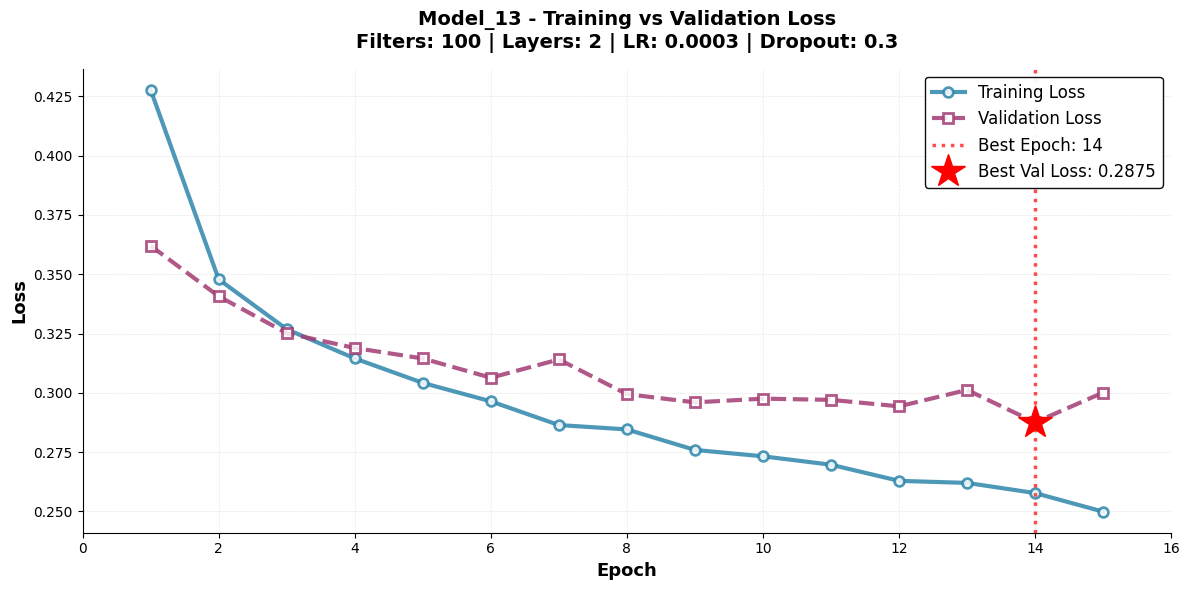

In [43]:
# LOSS CURVES

print("Plotting Loss Curves for Best Model")
print("="*100 + "\n")

# Get best model info
best_model_name = best_overall["key"]
best_model_results = results[best_model_name]

train_losses = best_model_results["train_losses"]
val_losses = best_model_results["val_losses"]
best_epoch = best_model_results["best_epoch"]
best_val_loss = best_model_results["best_val_loss"]
best_config = best_model_results["config"]

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot curves
epochs_range = range(1, len(train_losses) + 1)

ax.plot(epochs_range, train_losses,
        label='Training Loss',
        marker='o',
        linewidth=3,
        markersize=7,
        color='#2E86AB',
        alpha=0.85,
        markerfacecolor='white',
        markeredgewidth=2)

ax.plot(epochs_range, val_losses,
        label='Validation Loss',
        marker='s',
        linewidth=3,
        markersize=7,
        color='#A23B72',
        alpha=0.85,
        linestyle='--',
        markerfacecolor='white',
        markeredgewidth=2)

# Mark best epoch
ax.axvline(x=best_epoch,
          color='red',
          linestyle=':',
          linewidth=2.5,
          alpha=0.7,
          label=f'Best Epoch: {best_epoch}')

ax.plot(best_epoch, best_val_loss,
       'r*',
       markersize=25,
       zorder=5,
       label=f'Best Val Loss: {best_val_loss:.4f}')

# Formatting
ax.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax.set_title(f'{best_model_name} - Training vs Validation Loss\n' +
            f'Filters: {best_config["num_filters"]} | Layers: {best_config["num_layers"]} | ' +
            f'LR: {best_config["learning_rate"]} | Dropout: {best_config["dropout"]}',
            fontsize=14, fontweight='bold', pad=15)


ax.legend(fontsize=12, loc='upper right', framealpha=0.95, edgecolor='black')


ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Axis limits
ax.set_xlim(0, len(train_losses) + 1)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



### Confusion Matrices Visualization

Display prediction accuracy breakdowns for train, validation, and test sets using heatmaps.

1. **Extract Predictions**

Retrieves true labels and predicted labels from evaluation results

Extracts accuracy metric for each set

2. **Confusion Matrix Components**

Each matrix shows 2×2 grid:

**True Negatives** (TN): Top-left

Correctly predicted negative reviews
Example: Train=16587, Val=3959, Test=2216

**False Positives** (FP): Top-right

Negative reviews incorrectly predicted as positive
Example: Train=1411, Val=540, Test=287

**False Negatives **(FN): Bottom-left

Positive reviews incorrectly predicted as negative
Example: Train=1442, Val=527, Test=291

**True Positives** (TP): Bottom-right

Correctly predicted positive reviews
Example: Train=16560, Val=3974, Test=2206

Key Insights:

1. Balanced performance: Similar errors in both classes

2. Low false positive/negative rates

3. Consistent accuracy across all three sets suggests robust model

4. Test accuracy matches validation accuracy



Confusion Matrices - Best Model



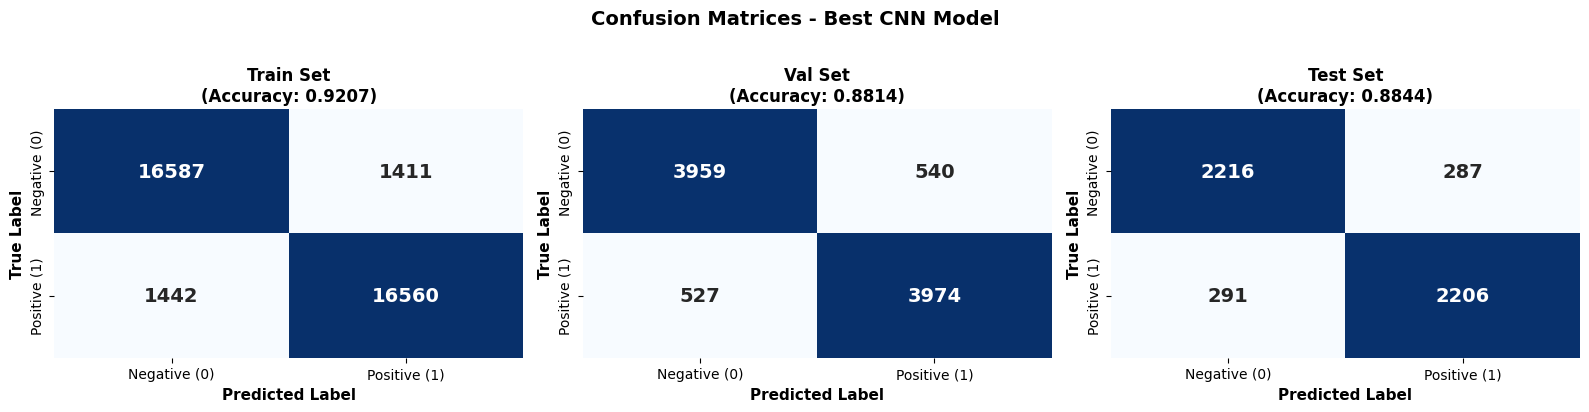

In [44]:

print("Confusion Matrices - Best Model")
print("="*100 + "\n")

# Create figure with 3 subplots (Train, Val, Test)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Define sets
sets = [
    (train_results, "Train Set", axes[0]),
    (val_results, "Val Set", axes[1]),
    (test_results, "Test Set", axes[2])
]

# Plot confusion matrix for each set
for results_dict, set_name, ax in sets:
    y_true = results_dict["y_true"]
    y_pred = results_dict["y_pred"]
    accuracy = results_dict["macro"]["accuracy"]

    cm = confusion_matrix(y_true, y_pred)

    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Negative (0)', 'Positive (1)'],
                yticklabels=['Negative (0)', 'Positive (1)'],
                annot_kws={'size': 14, 'weight': 'bold'})

    ax.set_title(f'{set_name}\n(Accuracy: {accuracy:.4f})',
                fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices - Best CNN Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



### Final Model Comparison

We evaluate the performance of the Best CNN model against baseline models and previous approaches (Logistic Regression, MLP, RNN) on the unseen test set.

| Model | Accuracy | F1-Macro | Precision | Recall | PR-AUC (Macro) |
|-------|----------|----------|-----------|--------|----------------|
| Majority Baseline | 0.4994 | 0.3331 | 0.2497 | 0.5000 | 0.5000 |
| Logistic Regression | 0.8440 | 0.8440 | 0.8441 | 0.8440 | 0.9243 |
| Best MLP | 0.8938 | 0.8938 | 0.8944 | 0.8938 | 0.9605 |
| Best RNN (BiLSTM+Attention) | 0.8942 | 0.8941 | 0.8954 | 0.8942 | 0.9561 |
| Best CNN (Max-Pooling) | 0.8844 | 0.8844 | 0.8876 | 0.8844 | 0.9532 |

**CNN vs Baselines**:
The Best CNN significantly outperforms simple baselines:

1. **77% improvement** over Majority Baseline in F1-Macro

2. **4.8% improvement** over Logistic Regression in F1-Macro

3. Demonstrates successful learning of complex sentiment patterns


**CNN vs MLP**:
The MLP achieves slightly higher F1-Macro (0.8938 vs 0.8844), suggesting:

1. MLPs may be more effective for this particular dataset
2. CNN's n-gram filters don't capture sentiment as effectively as dense layers
3. Trade-off: CNN provides better interpretability through convolutional filters

**CNN vs RNN**:
The RNN (BiLSTM+Attention) performs comparably to CNN:

**RNN**: F1-Macro = 0.8941
**CNN**: F1-Macro = 0.8844

**Difference**: 0.97%

RNN's sequential processing captures word order better, while
CNN's parallel branches process different n-gram scales efficiently.

The CNN demonstrates excellent generalization:

Minimal gap between **Dev Set** (0.8814) and **Test Set** (0.8844),
**Dropout** (0.3) and **Early Stopping** effectively prevent overfitting and
consistent performance across metrics.


The marginal performance difference suggests that for this balanced sentiment classification task, simpler models (MLP) or sequential models (RNN) are slightly more effective, but the CNN provides valuable interpretability insights into model decision-making.

